![Imgur](https://i.imgur.com/h4PPC71.png)
#**19-modul. Unsupervised learning. Clustering**
# 19.8. Modul boʻyicha yakuniy amaliy vazifa. Mijozlarni xarajat turlariga qarab segmentlash

**Ushbu vazifa orqali siz:**

✔️ klasterlash;

✔️ maʼlumotlarni normallashtirish;

✔️ klaster tahlili;

✔️ vizualizatsiya kabi real data sayns loyihalari uchun zarur texnik ko‘nikmalarga ega bo‘lasiz.

## **Dataset: Wholesale Customers Data**  
- **Manba:** [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/wholesale+customers)  
- **Hajmi:** **22 KB**
- **Format:** CSV  
- **Tavsif:** bu dataset **ulgurji savdo mijozlarini** xarajatlar bo‘yicha klasterlash uchun ishlatiladi.  
  U quyidagi xarajat kategoriyalarini o‘z ichiga oladi:  
  - **channel** (mijoz turi: 1 – HoReCa (mehmonxona, restoran, kafelar) yoki 2 – chakana savdo)  
  - **region** (hudud: 1 – Lisbon, 2 – Oporto, 3 – boshqa)  
  - **fresh** (yangi mahsulotlarga sarf qilingan summa)  
  - **milk** (sut mahsulotlariga sarf qilingan summa)  
  - **grocery** (oziq-ovqat mahsulotlariga sarf qilingan summa)  
  - **frozen** (muzlatilgan mahsulotlarga sarf qilingan summa)  
  - **Detergents_Paper** (kimyoviy tozalash va qog‘oz mahsulotlari)  
  - **delicassen** (delikates mahsulotlar)  

---

### **Vazifa: mijozlarni xarajat turlariga qarab segmentlash**  
Maqsad – **mijozlarni xarajat qiladigan mahsulotlar bo‘yicha klasterlash va marketologlarga tavsiyalar berish**  

---

### **Klasterlash bosqichlari**  
1) **Maʼlumotlarni tayyorlash**  
   - `Channel` va `Region` ustunlarini olib tashlang yoki kodlang.  
   - Har bir xarajat ustunini **normalizatsiya qiling**.  

2) **K-means klasterlashni amalga oshirish**  
   - K-means yordamida mijozlarni **xarajat qilish odatlari** bo‘yicha segmentlarga ajrating.  

3) **Natijalarni vizualizatsiya qilish**  
   - **Pairplot yoki scatter plot** yordamida klasterlarni ko‘rsating.  
   - Har bir segmentning xarajatlar bo‘yicha o‘rtacha qiymatini diagrammada aks ettiring.

---

###*** ESLATMA**: *Ushbu amaliy vazifada siz oʻtmagan mavzulardan ham savollar va vazifalar boʻlishi mumkin! Bu savollarni mustaqil oʻrganishingiz kerak boʻladi. Bunday vazifalar mustaqil izlanish koʻnikmangizni oshirish uchun tayyorlandi!*

In [30]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans


In [31]:

df = pd.read_csv("https://raw.githubusercontent.com/alishermutalov/praktikum-datasets/refs/heads/praktikum/Wholesale_customers_data.csv")
df.head()


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


# 1. Maʼlumotlarni tayyorlash

1. Channel va Region ustunlarini olib tashlang yoki kodlang.
2. Har bir xarajat ustunini normalizatsiya qiling.

In [32]:
df = df.drop(columns = ["Channel", "Region"])
df.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,12669,9656,7561,214,2674,1338
1,7057,9810,9568,1762,3293,1776
2,6353,8808,7684,2405,3516,7844
3,13265,1196,4221,6404,507,1788
4,22615,5410,7198,3915,1777,5185


In [33]:
df.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,12669,9656,7561,214,2674,1338
1,7057,9810,9568,1762,3293,1776
2,6353,8808,7684,2405,3516,7844
3,13265,1196,4221,6404,507,1788
4,22615,5410,7198,3915,1777,5185


In [34]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)
df = pd.DataFrame(data=scaled_data, columns=df.columns)
df = df.abs()
df

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0.052933,0.523568,0.041115,0.589367,0.043569,0.066339
1,0.391302,0.544458,0.170318,0.270136,0.086407,0.089151
2,0.447029,0.408538,0.028157,0.137536,0.133232,2.243293
3,0.100111,0.624020,0.392977,0.687144,0.498588,0.093411
4,0.840239,0.052396,0.079356,0.173859,0.231918,1.299347
...,...,...,...,...,...,...
435,1.401312,0.848446,0.850760,2.075222,0.566831,0.241091
436,2.155293,0.592142,0.757165,0.296561,0.585519,0.291501
437,0.200326,1.314671,2.348386,0.543380,2.511218,0.121456
438,0.135384,0.517536,0.602514,0.419441,0.569770,0.213046


# 2 K-means klasterlashni amalga oshirish

K-means yordamida mijozlarni xarajat qilish odatlari bo‘yicha segmentlarga ajrating.

In [35]:
X_train, X_test = train_test_split(df, train_size=0.8, random_state=42)

In [39]:
model = KMeans(init = "random", n_clusters = 4, n_init = 15)
model.fit(X_train)


KMeans(init='random', n_clusters=4, n_init=15)

In [40]:
model.cluster_centers_

array([[0.61172881, 1.54404759, 1.86144722, 0.37497885, 1.89064405,
        0.9425985 ],
       [1.80335587, 3.33298726, 0.9425185 , 9.4098007 , 0.44640902,
        8.96415723],
       [0.67176445, 0.44622538, 0.48968077, 0.49216375, 0.48452778,
        0.342829  ],
       [1.14514574, 4.6373064 , 5.36363652, 0.51554921, 5.48784726,
        0.46652949]])

In [41]:
model.labels_

array([2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 2, 0,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 0, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 2, 0, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 2, 2,
       2, 2, 1, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 3,
       2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 3, 3, 2, 2, 0, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2,
       2, 2, 2, 0, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,

# 3 Natijalarni vizualizatsiya qilish

1. Pairplot yoki scatter plot yordamida klasterlarni ko‘rsating.
2. Har bir segmentning xarajatlar bo‘yicha o‘rtacha qiymatini diagrammada aks ettiring.

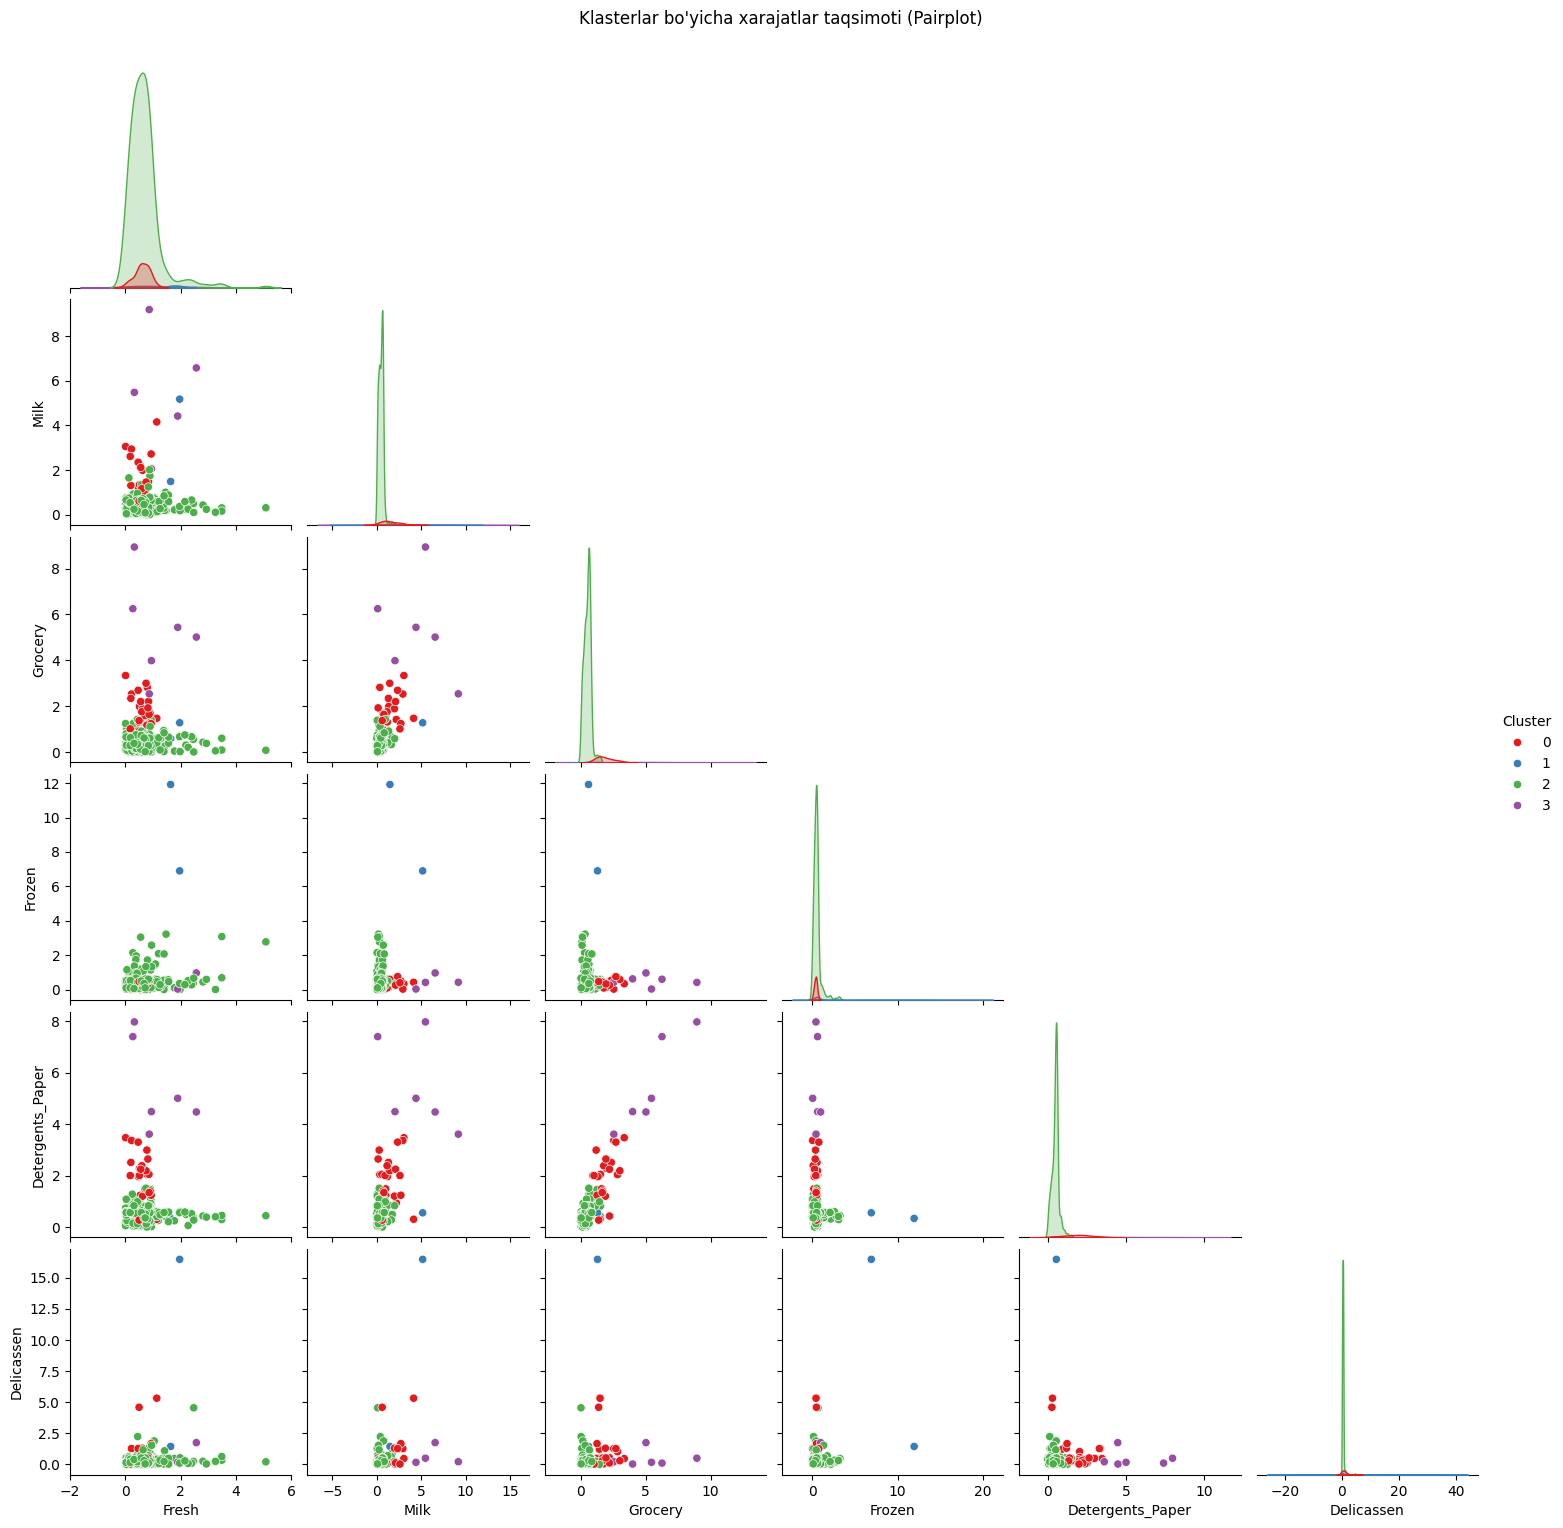

In [43]:
# 1. X_train nusxasini olib, klaster yorliqlarini qo'shamiz
X_train_df = X_train.copy()
X_train_df['Cluster'] = model.labels_

# 2. Pairplot chizamiz
sns.pairplot(X_train_df, hue='Cluster', palette='Set1', corner=True)
plt.suptitle("Klasterlar bo'yicha xarajatlar taqsimoti (Pairplot)", y=1.02)
plt.show()

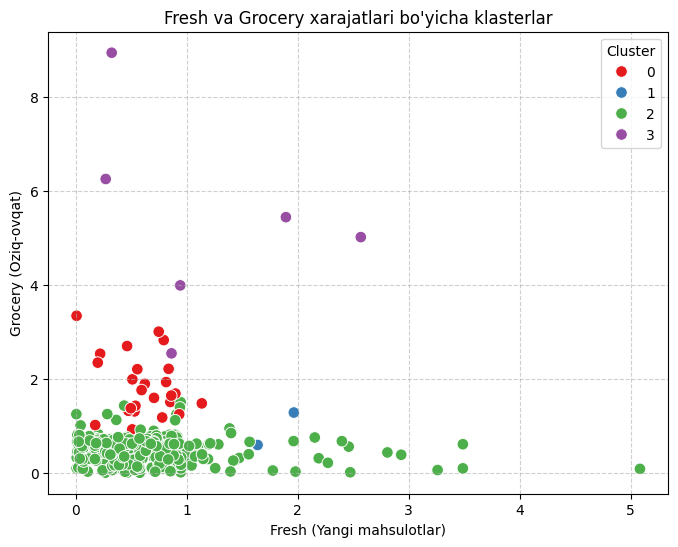

In [44]:
# 1. X_train nusxasiga klasterlarni qo'shamiz (agar yuqoridagi qadam bajarilmagan bo'lsa)
X_train_df = X_train.copy()
X_train_df['Cluster'] = model.labels_

# 2. Scatter plot chizamiz (x va y uchun xohlagan xarajat ustunini tanlashingiz mumkin)
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=X_train_df,
    x='Fresh',
    y='Grocery',
    hue='Cluster',
    palette='Set1',
    s=70
)

plt.title("Fresh va Grocery xarajatlari bo'yicha klasterlar")
plt.xlabel("Fresh (Yangi mahsulotlar)")
plt.ylabel("Grocery (Oziq-ovqat)")
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()